# Detekcja anomalii w ruchu sieciowym

_Damian Urbański_

## Importowanie bibliotek

In [ ]:
import os
import tensorflow as tf
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import random
sns.set_theme()
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.metrics import R2Score

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Analiza danych

In [3]:
kolumny = []
with open("kddcup.names", "r") as plik_nazw:
    linie = plik_nazw.readlines()

for linia in linie[1:]:
    if ":" in linia:
        nazwa = linia.split(":")[0]
        kolumny.append(nazwa)

kolumny.append("outcome")

df = pd.read_csv("kddcup.data_10_percent.gz", header=None, names=kolumny)
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,tcp,http,SF,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.
494017,0,tcp,http,SF,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.
494018,0,tcp,http,SF,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal.
494019,0,tcp,http,SF,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

In [5]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494021.000000,4.940210e+05,4.940210e+05,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,...,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000
mean,47.979302,3.025610e+03,8.685324e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148247,0.010212,...,232.470778,188.665670,0.753780,0.030906,0.601935,0.006684,0.176754,0.176443,0.058118,0.057412
std,707.746472,9.882181e+05,3.304000e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355345,1.798326,...,64.745380,106.040437,0.410781,0.109259,0.481309,0.042133,0.380593,0.380919,0.230590,0.230140
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
pd.DataFrame(data= [df['outcome'].value_counts(),df['outcome'].value_counts(normalize=True) * 100]).T

,count,proportion
outcome,,
smurf.,280790.0,56.837665
neptune.,107201.0,21.699685
normal.,97278.0,19.691066
back.,2203.0,0.445932
satan.,1589.0,0.321646
ipsweep.,1247.0,0.252418
portsweep.,1040.0,0.210517
warezclient.,1020.0,0.206469
teardrop.,979.0,0.198170


In [7]:
df.skew(numeric_only=True)

,0
duration,25.864857
src_bytes,699.213151
dst_bytes,136.759278
land,149.842038
wrong_fragment,21.718929
urgent,447.647005
hot,32.629145
num_failed_logins,160.802616
logged_in,1.979794
num_compromised,417.530228


In [8]:
df.kurt(numeric_only=True)

,0
duration,942.530243
src_bytes,490584.345621
dst_bytes,20338.143392
land,22450.727280
wrong_fragment,476.087532
urgent,217366.710210
hot,1127.017237
num_failed_logins,37221.597084
logged_in,1.919592
num_compromised,188121.347708


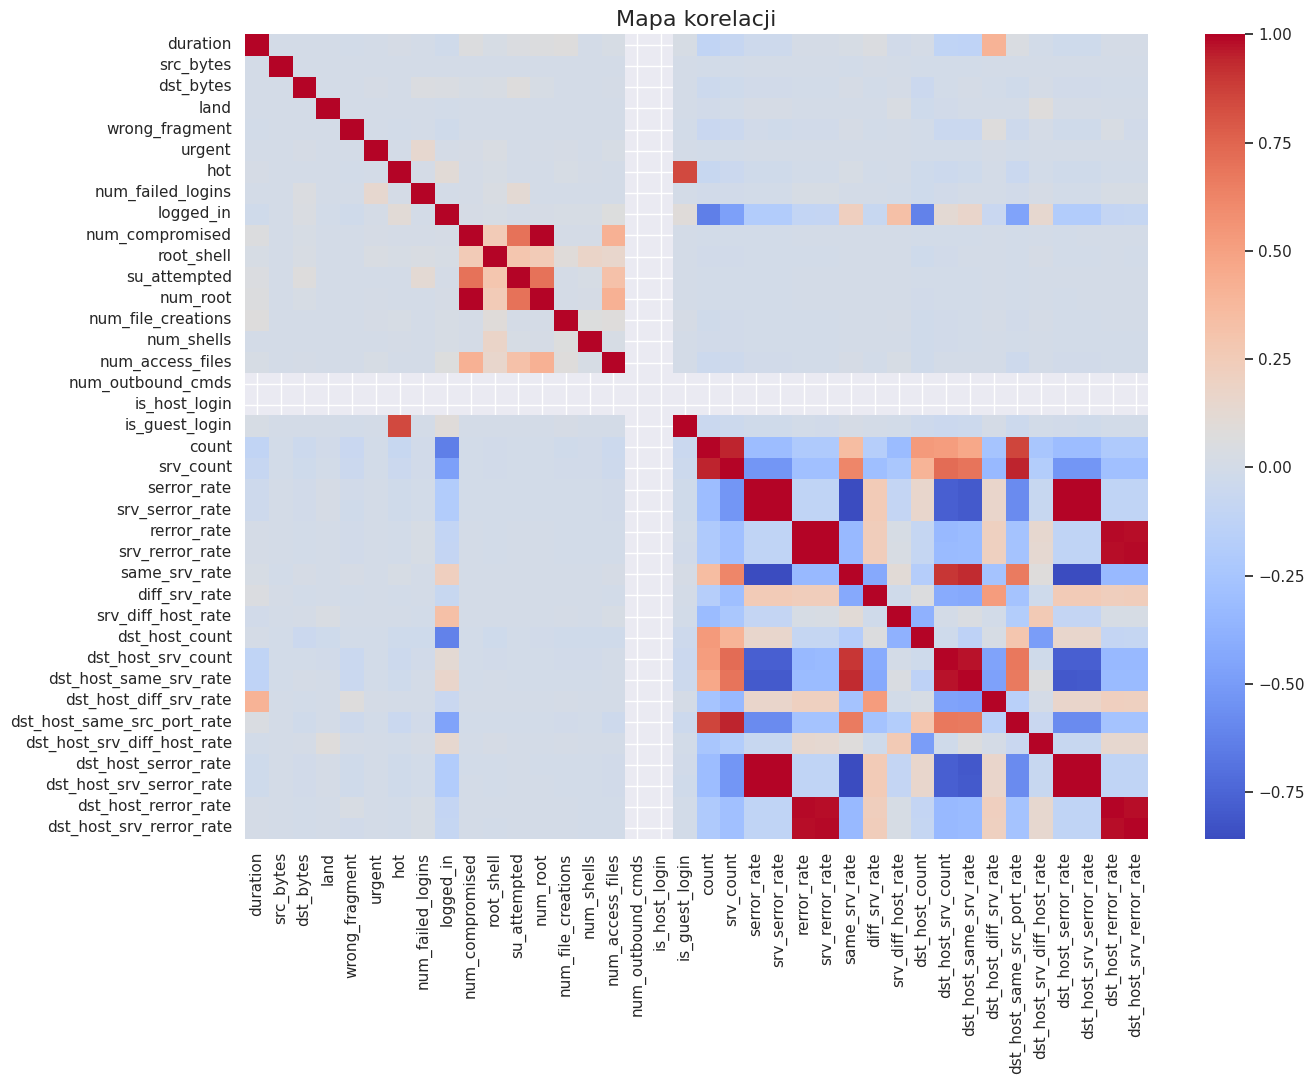

In [9]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, cbar=True)
plt.title("Mapa korelacji", fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
print("'num_outbound_cmds':", df['num_outbound_cmds'].unique())
print("'is_host_login':",    df['is_host_login'].unique())

'num_outbound_cmds': [0]
'is_host_login': [0]


Usuwam kolumny `num_outbound_cmds` oraz `is_host_login` ponieważ na całej długości danych mają one tylko jedną, stałą wartość.

In [11]:
df = df.drop(columns= ['num_outbound_cmds', 'is_host_login'])

In [12]:
df.isna().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


Brak pustych rekordów.

/tmp/ipykernel_6277/3875242256.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


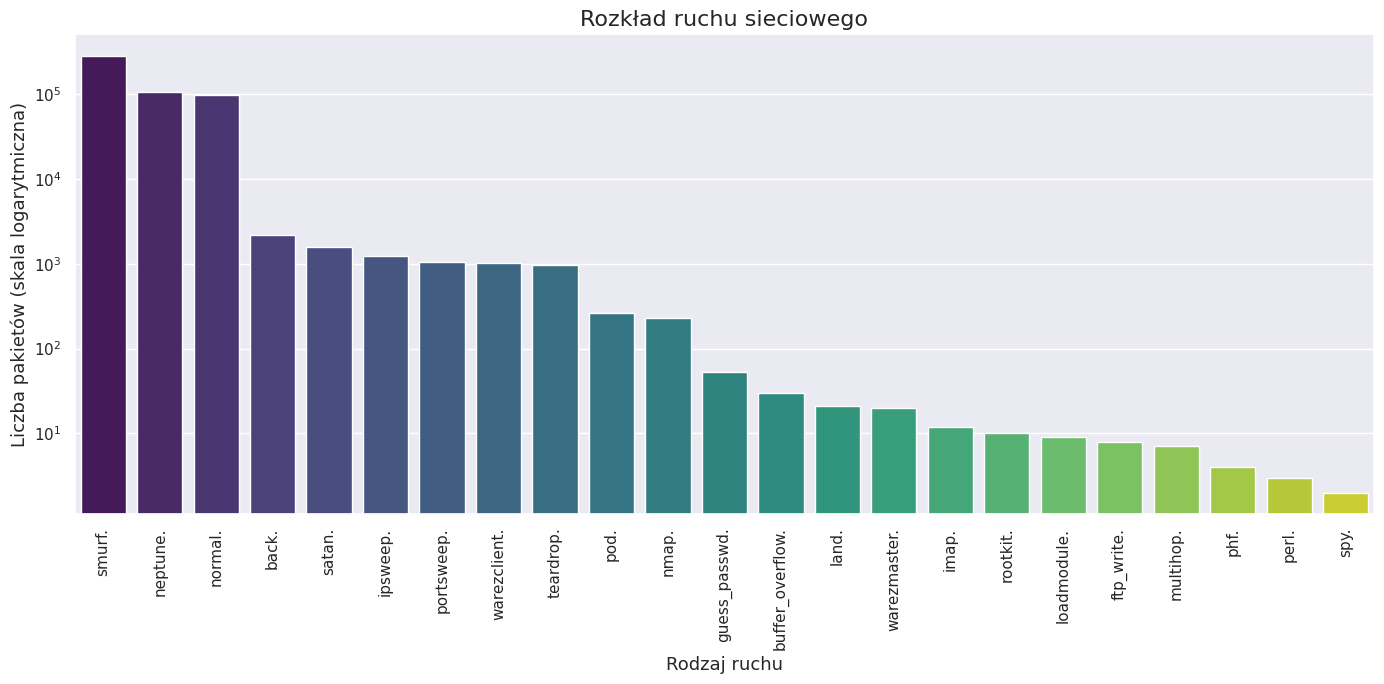

In [13]:
plt.figure(figsize=(14, 7))
sns.countplot(
    data=df, 
    x='outcome', 
    order=df['outcome'].value_counts().index,
    palette="viridis"
)
plt.yscale('log')
plt.xticks(rotation=90, fontsize=11)
plt.xlabel("Rodzaj ruchu", fontsize=13)
plt.ylabel("Liczba pakietów (skala logarytmiczna)", fontsize=13)
plt.title("Rozkład ruchu sieciowego", fontsize=16)

plt.tight_layout()
plt.show()

In [14]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [15]:
train_normal = train_df[train_df['outcome']=='normal.'].drop(columns=['outcome'])
train_anom = train_df[train_df['outcome'] !='normal.'].drop(columns=['outcome'])
test_normal = test_df[test_df['outcome']=='normal.'].drop(columns=['outcome'])
test_anom = test_df[test_df['outcome'] !='normal.'].drop(columns=['outcome'])

In [16]:
print("Wymiary przed przygotowaniem danych:")
print(f"train_normal: {train_normal.shape}, train_anom: {train_anom.shape}")
print(f"test_normal:  {test_normal.shape},  test_anom:  {test_anom.shape}\n")

Wymiary przed przygotowaniem danych:
train_normal: (77925, 39), train_anom: (317291, 39)
test_normal:  (19353, 39),  test_anom:  (79452, 39)



In [17]:
categorical_cols = train_normal.select_dtypes(include=['object']).columns.tolist()
numeric_cols = train_normal.select_dtypes(exclude=['object']).columns.tolist()

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        # w OneHotEncoder używam handle_unknown = 'ignore', ponieważ w zbiorze z anomaliami występuje więcej wartości dla cech kategorycznych
        # Ale nie wszystkie musimy zakodować, ponieważ zadaniem autoenkodera jest poprawne odwzorowanie normalnego ruchu sieciowego
        # Dodatkowe cechy, wskazujące na anomalię mogłyby zakłócać działanie autoenkodera 
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output=False),categorical_cols )
    ]
)


In [19]:
train_normal_prep = preprocessor.fit_transform(train_normal)

train_anom_prep = preprocessor.transform(train_anom)
test_normal_prep = preprocessor.transform(test_normal)
test_anom_prep = preprocessor.transform(test_anom)

print(f"train_normal_prep: {train_normal_prep.shape}")
print(f"train_anom_prep:   {train_anom_prep.shape}")
print(f"test_normal_prep:  {test_normal_prep.shape}")
print(f"test_anom_prep:    {test_anom_prep.shape}")

train_normal_prep: (77925, 72)
train_anom_prep:   (317291, 72)
test_normal_prep:  (19353, 72)
test_anom_prep:    (79452, 72)


## Przypadek 1

- Model podstawowy 
- (128) -> (32) -> (8) -> (32) -> (128)
- Optymalizator Adam

In [ ]:
autoencoder = Sequential([
    Input(shape= (train_normal_prep.shape[1],)),

    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(8, activation='relu'),

    Dense(32, activation='relu'),
    Dense(128, activation='relu'),

    Dense(train_normal_prep.shape[1], activation='sigmoid')
])

In [ ]:
autoencoder.compile(
    optimizer= 'adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 72)             │         9,288 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,536 (107.56 KB)

 Trainable params: 27,536 (107.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = autoencoder.fit(
    x=train_normal_prep, 
    y=train_normal_prep,
    epochs=100,
    batch_size=128,
    validation_data=(test_normal_prep, test_normal_prep),
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.0461 - loss: 0.0704 - val_accuracy: 0.0010 - val_loss: 0.0228
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0566 - loss: 0.0211 - val_accuracy: 0.4177 - val_loss: 0.0201
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3233 - loss: 0.0194 - val_accuracy: 0.6449 - val_loss: 0.0191
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3938 - loss: 0.0186 - val_accuracy: 0.6362 - val_loss: 0.0185
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4242 - loss: 0.0182 - val_accuracy: 0.6524 - val_loss: 0.0182
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4655 - loss: 0.0179 - val_accuracy: 0.6585 - val_loss: 0.0180
Epoch 7/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4783 - loss: 0.0177 - val_accuracy: 0.6548 - val_loss: 0.0178
Epoch 8/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5036 - loss: 0.0176 - val_accu

In [20]:
def plot_history(history):

    fig, ax = plt.subplots()
    ax.plot(history.history['loss'], label="loss", color='blue')
    ax.plot(history.history['val_loss'], label='val_loss', color= 'orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel("Loss")
    ax.legend(loc="upper left")

    ax2 = ax.twinx()
    ax2.plot(history.history['accuracy'], label='accuracy', color='green')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy', color='red')
    ax2.set_ylabel("Accuracy")
    ax2.legend(loc='upper right')

    plt.show()

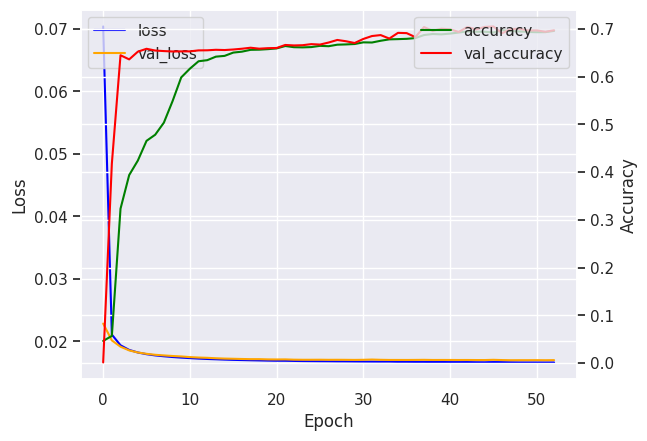

In [ ]:
plot_history(history)

In [ ]:
train_norm_pred = autoencoder.predict(train_normal_prep)
test_norm_pred = autoencoder.predict(test_normal_prep)
test_anom_pred = autoencoder.predict(test_anom_prep)
train_anom_pred = autoencoder.predict(train_anom_prep)

2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
9916/9916 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


In [ ]:
train_norm_errors = np.mean(np.abs(train_normal_prep - train_norm_pred), axis=1)
test_norm_errors = np.mean(np.abs(test_normal_prep - test_norm_pred), axis=1)
test_anom_errors = np.mean(np.abs(test_anom_prep - test_anom_pred), axis=1)
train_anom_errors = np.mean(np.abs(train_anom_prep - train_anom_pred), axis=1)

y_scores_test = np.concatenate([test_norm_errors, test_anom_errors])
y_true_test = np.concatenate([np.zeros(len(test_norm_errors)), np.ones(len(test_anom_errors))])

In [ ]:
print(f"Max MAE Train Normal: {np.max(train_norm_errors):.2f}")
print(f"Max MAE Test Normal: {np.max(test_norm_errors):.2f}")
print(f"Max MAE Test Anomaly: {np.max(test_anom_errors):.2f}")
print(f"Max MAE Train Anomaly: {np.max(train_anom_errors):.2f}")

Max MAE Train Normal: 0.05
Max MAE Test Normal: 0.09
Max MAE Test Anomaly: 0.20
Max MAE Train Anomaly: 4.54


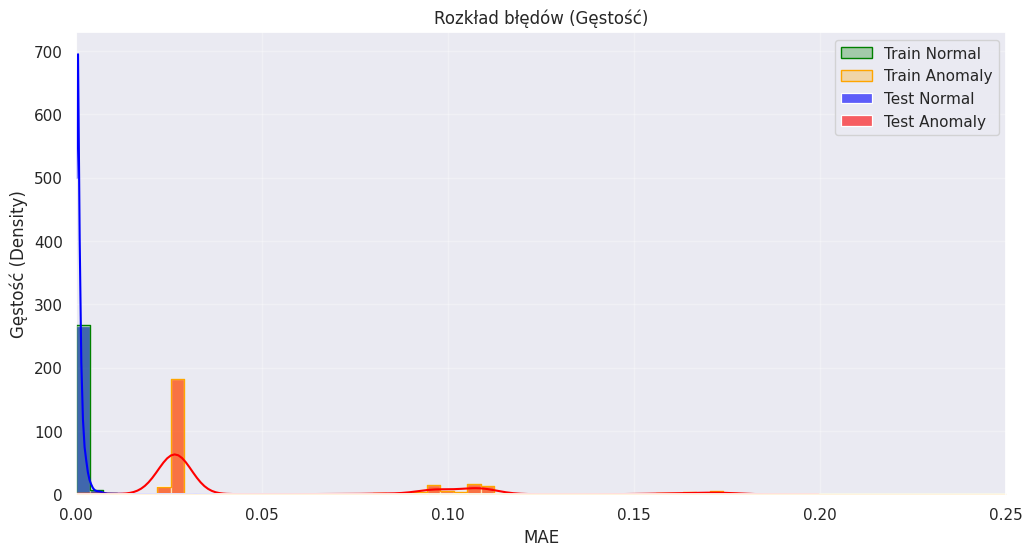

In [ ]:
plt.figure(figsize=(12, 6))

my_bins = np.linspace(0, 0.25, 70) 

sns.histplot(test_norm_errors, bins=my_bins, kde=True, color='blue', label='Test Normal', alpha=0.6, stat='density')
sns.histplot(test_anom_errors, bins=my_bins, kde=True, color='red', label='Test Anomaly', alpha=0.6, stat='density')
sns.histplot(train_norm_errors, bins=my_bins, kde=False, color='green', label='Train Normal', alpha=0.3, element='step', stat='density')
sns.histplot(train_anom_errors, bins=my_bins, kde=False, color='orange', label='Train Anomaly', alpha=0.3, element='step', stat='density')

plt.title('Rozkład błędów (Gęstość)')
plt.xlabel('MAE')
plt.ylabel('Gęstość (Density)')

plt.xlim(0, 0.25) 

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

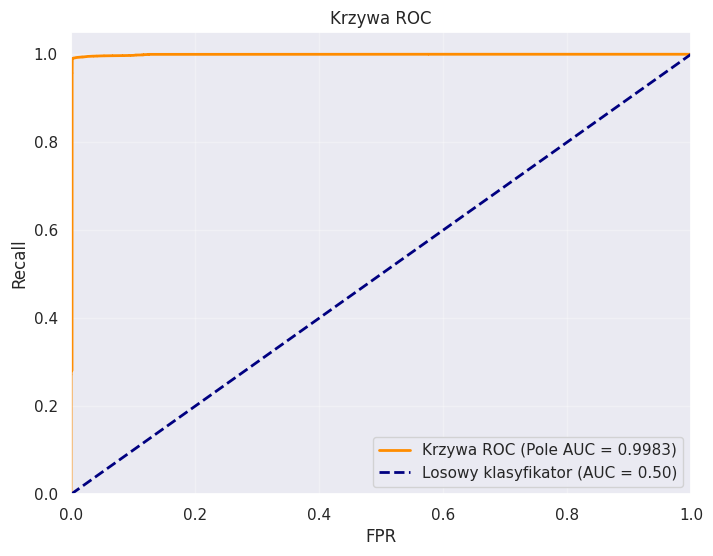

Wartość metryki AUC: 0.9983


In [ ]:
fpr_roc, tpr_roc, thresholds_roc = roc_curve(y_true_test, y_scores_test)
roc_auc = auc(fpr_roc, tpr_roc)

plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=2, label=f'Krzywa ROC (Pole AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowy klasyfikator (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('Recall')
plt.title('Krzywa ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Wartość metryki AUC: {roc_auc:.4f}")

In [ ]:
# żeby znaleźć odpowiedni punkt odcięcia zastosuję wskaźnik J Youdena: J= TPR - FPR
j_scores = tpr_roc - fpr_roc

best_idx = np.argmax(j_scores)

threshold = thresholds_roc[best_idx]

print(f"Optymalny próg(wsk. J Youdena): {threshold:.4f}")
print(f"Maksymalna wartość wsk J Youdena: {j_scores[best_idx]:.4f}")

Optymalny próg(wsk. J Youdena): 0.0196
Maksymalna wartość wsk J Youdena: 0.9882


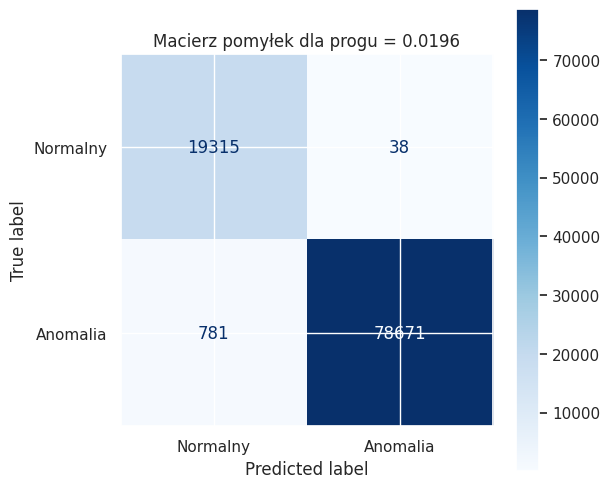


Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

    Normalny       0.96      1.00      0.98     19353
    Anomalia       1.00      0.99      0.99     79452

    accuracy                           0.99     98805
   macro avg       0.98      0.99      0.99     98805
weighted avg       0.99      0.99      0.99     98805

Wskaźnik Fałszywych Alarmów (FPR): 0.20%


In [ ]:
y_pred_test = (y_scores_test > threshold).astype(int)

cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normalny', 'Anomalia'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Macierz pomyłek dla progu = {threshold:.4f}')
plt.show()

print("\nSzczegółowy raport klasyfikacji:")
print(classification_report(y_true_test, y_pred_test, target_names=['Normalny', 'Anomalia']))

tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
print(f"Wskaźnik Fałszywych Alarmów (FPR): {fpr*100:.2f}%")

### Wnioski

Model bazowy wykorzystujący optymalizator Adam charakteryzuje się bardzo wysoką stabilnością procesu uczenia. Krzywa uczenia przebiega gładko, a funkcja straty stabilnie spada do poziomu około 0.017, co potwierdza, że autoenkoder bardzo dobrze odwzorowuje normalny ruch sieciowy i skutecznie reaguje wyraźnym wzrostem błędu MAE na każdą anomalię. Przy wyznaczonym przez wskaźnik J Youdena progu odcięcia wynoszącym 0.0196, model osiąga świetną czułość na poziomie 99% przy jednoczesnym ograniczeniu wskaźnika fałszywych alarmów (FPR) do zaledwie 0.20%. W praktyce przekłada się to na przechwycenie niemal wszystkich zagrożeń (jedynie 781 przepuszczonych ataków na blisko 80 tysięcy) oraz tylko 38 pomyłek na ponad 19 tysięcy normalnych próbek. Wynik AUC równy 0.9983 potwierdza wysoką skuteczność klasyfikacji.

In [22]:
def generate_model_summary(model,
                           train_normal_prep, test_normal_prep, test_anom_prep, train_anom_prep,
                           bins=70, x_min=0, x_max=0.25):
    
    train_norm_pred = model.predict(train_normal_prep)
    test_norm_pred = model.predict(test_normal_prep)
    test_anom_pred = model.predict(test_anom_prep)
    train_anom_pred = model.predict(train_anom_prep)

    train_norm_errors = np.mean(np.abs(train_normal_prep - train_norm_pred), axis=1)
    test_norm_errors = np.mean(np.abs(test_normal_prep - test_norm_pred), axis=1)
    test_anom_errors = np.mean(np.abs(test_anom_prep - test_anom_pred), axis=1)
    train_anom_errors = np.mean(np.abs(train_anom_prep - train_anom_pred), axis=1)

    y_scores_test = np.concatenate([test_norm_errors, test_anom_errors])
    y_true_test = np.concatenate([np.zeros(len(test_norm_errors)), np.ones(len(test_anom_errors))])

    plt.figure(figsize=(12, 6))

    my_bins = np.linspace(x_min, x_max, bins) 

    sns.histplot(test_norm_errors, bins=my_bins, kde=True, color='blue', label='Test Normal', alpha=0.6, stat='density')
    sns.histplot(test_anom_errors, bins=my_bins, kde=True, color='red', label='Test Anomaly', alpha=0.6, stat='density')
    sns.histplot(train_norm_errors, bins=my_bins, kde=False, color='green', label='Train Normal', alpha=0.3, element='step', stat='density')
    sns.histplot(train_anom_errors, bins=my_bins, kde=False, color='orange', label='Train Anomaly', alpha=0.3, element='step', stat='density')

    plt.title('Rozkład błędów (Gęstość)')
    plt.xlabel('MAE')
    plt.ylabel('Gęstość (Density)')

    plt.xlim(x_min, x_max) 

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    fpr_roc, tpr_roc, thresholds_roc = roc_curve(y_true_test, y_scores_test)
    roc_auc = auc(fpr_roc, tpr_roc)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=2, label=f'Krzywa ROC (Pole AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowy klasyfikator (AUC = 0.50)')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('FPR')
    plt.ylabel('Recall')
    plt.title('Krzywa ROC')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    print('_'*40)
    print(f"Wartość metryki AUC: {roc_auc:.4f}")

    j_scores = tpr_roc - fpr_roc

    best_idx = np.argmax(j_scores)

    threshold = thresholds_roc[best_idx]

    print(f"Optymalny próg(wsk. J Youdena): {threshold:.4f}")
    print(f"Maksymalna wartość wsk J Youdena: {j_scores[best_idx]:.4f}")
    print('_'*40)
    y_pred_test = (y_scores_test > threshold).astype(int)

    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normalny', 'Anomalia'])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f'Macierz pomyłek dla progu = {threshold:.4f}')
    plt.show()

    print('_'*40)
    print("\nSzczegółowy raport klasyfikacji:")
    print(classification_report(y_true_test, y_pred_test, target_names=['Normalny', 'Anomalia']))

    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    print(f"Wskaźnik Fałszywych Alarmów (FPR): {fpr*100:.2f}%")
    print('_'*40)

## Przypadek 2

- Algorytm RMSprop

In [ ]:
autoencoder = Sequential([
    Input(shape= (train_normal_prep.shape[1],)),

    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(8, activation='relu'),

    Dense(32, activation='relu'),
    Dense(128, activation='relu'),

    Dense(train_normal_prep.shape[1], activation='sigmoid')
])

In [ ]:
autoencoder.compile(
    optimizer= 'RMSprop', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = autoencoder.fit(
    x=train_normal_prep, 
    y=train_normal_prep,
    epochs=100,
    batch_size=128,
    validation_data=(test_normal_prep, test_normal_prep),
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0961 - loss: 0.0801 - val_accuracy: 0.3241 - val_loss: 0.0339
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3859 - loss: 0.0297 - val_accuracy: 0.4307 - val_loss: 0.0276
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3426 - loss: 0.0264 - val_accuracy: 0.3869 - val_loss: 0.0258
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3332 - loss: 0.0249 - val_accuracy: 0.4074 - val_loss: 0.0255
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3172 - loss: 0.0239 - val_accuracy: 0.3485 - val_loss: 0.0240
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2987 - loss: 0.0231 - val_accuracy: 0.2815 - val_loss: 0.0231
Epoch 7/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2827 - loss: 0.0223 - val_accuracy: 0.2756 - val_loss: 0.0220
Epoch 8/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2720 - loss: 0.0215 - val_accu

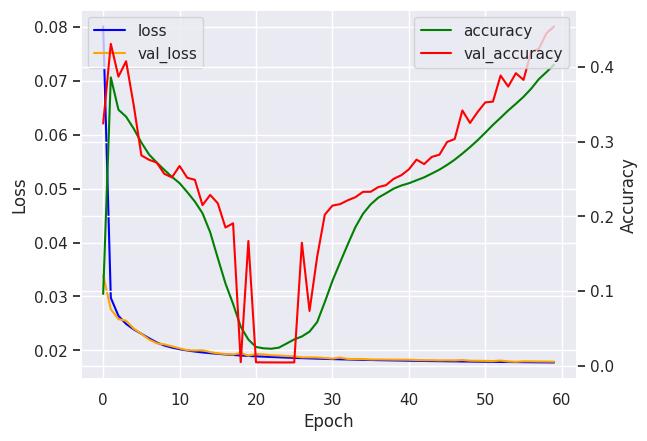

In [ ]:
plot_history(history)

2436/2436 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
9916/9916 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


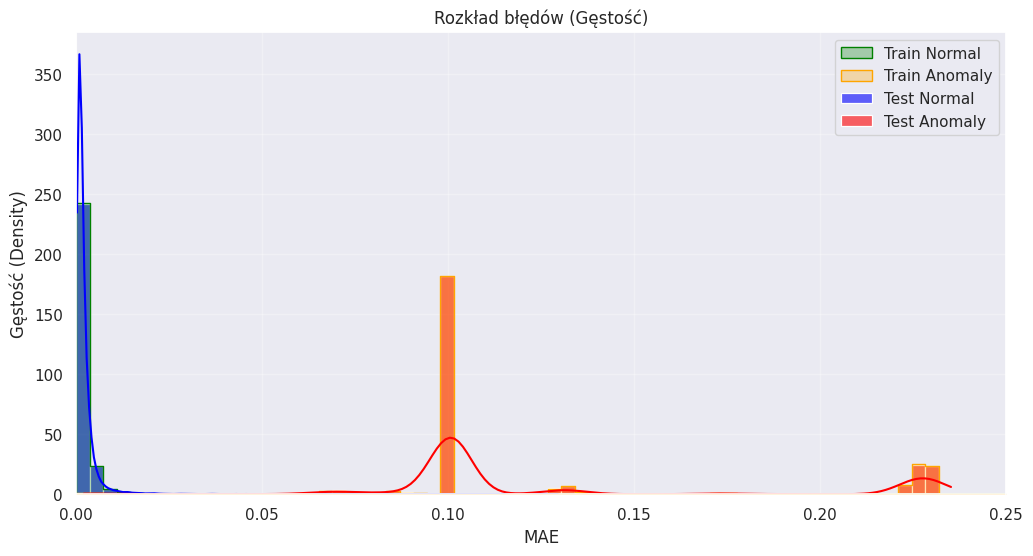

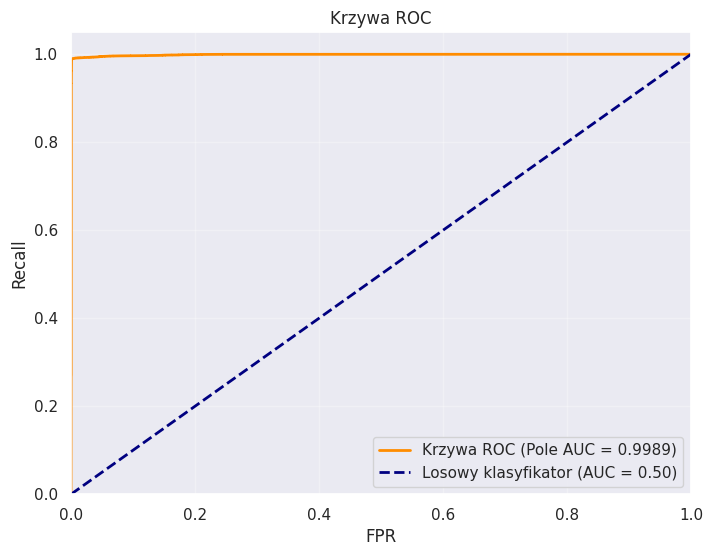

________________________________________
Wartość metryki AUC: 0.9989
Optymalny próg(wsk. J Youdena): 0.0496
Maksymalna wartość wsk J Youdena: 0.9882
________________________________________


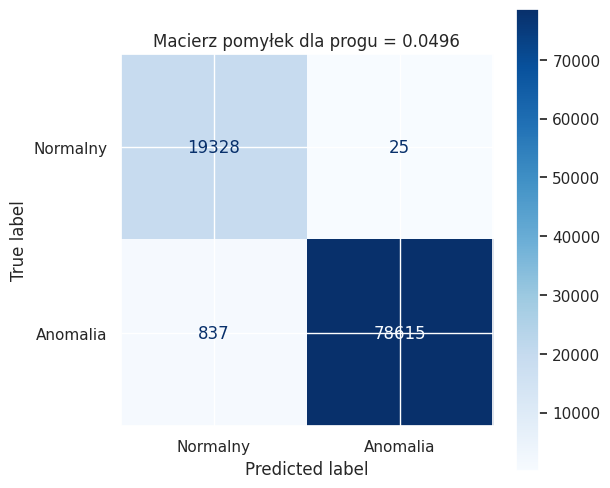

________________________________________

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

    Normalny       0.96      1.00      0.98     19353
    Anomalia       1.00      0.99      0.99     79452

    accuracy                           0.99     98805
   macro avg       0.98      0.99      0.99     98805
weighted avg       0.99      0.99      0.99     98805

Wskaźnik Fałszywych Alarmów (FPR): 0.13%
________________________________________


In [ ]:
generate_model_summary(autoencoder,
                           train_normal_prep, test_normal_prep, test_anom_prep, train_anom_prep)

Model wykorzystujący optymalizator RMSprop charakteryzuje się dużą niestabilnością procesu uczenia, co potwierdzają gwałtowne oscylacje i wyraźne spadki na wykresie metryk w okolicach 20 epoki. Mimo problemów model ostatecznie osiąga minimalnie wyższy wynik AUC równy 0.9989 oraz świetny wskaźnik FPR na poziomie 0.13%, co przekłada się na zaledwie 25 pomyłek na ponad 19 tysięcy normalnych próbek. Przy zbliżonej ogólnej czułości wynoszącej 99%, RMSprop wykazuje jednak wyższe ryzyko w kontekście detekcji intruzów, ponieważ przepuszcza o 56 zagrożeń więcej niż Adam (łącznie 837 nieprzepuszczonych ataków na blisko 80 tysięcy).

### Wnioski

Mimo że RMSprop osiągnął minimalnie wyższą wartość metryki AUC (0.9989 vs 0.9983) oraz niższy wskaźnik fałszywych alarmów (0.13% vs 0.20%), to optymalizator Adam zostaje wybrany jako rozwiązanie finalne. Adam charakteryzuje się znacznie wyższą stabilnością procesu uczenia, eliminując gwałtowne oscylacje widoczne w przypadku RMSprop. Ponadto, z punktu widzenia bezpieczeństwa sieciowego, Adam okazał się skuteczniejszy w wykrywaniu realnego zagrożenia, generując mniejszą liczbę błędów typu False Negative (781 przepuszczonych pakietów anomalnych względem 837 w RMSprop).

W związku z czym dalsze przypadku będą rozpatrywane z algorytmem Adam.


## Przypadek 3

- Dodanie warstw Dropout

In [ ]:
autoencoder = Sequential([
    Input(shape= (train_normal_prep.shape[1],)),

    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(8, activation='relu'),

    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),

    Dense(train_normal_prep.shape[1], activation='sigmoid')
])
autoencoder.compile(
    optimizer= 'adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = autoencoder.fit(
    x=train_normal_prep, 
    y=train_normal_prep,
    epochs=100,
    batch_size=128,
    validation_data=(test_normal_prep, test_normal_prep),
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.0406 - loss: 0.0762 - val_accuracy: 1.0334e-04 - val_loss: 0.0256
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0161 - loss: 0.0264 - val_accuracy: 1.5501e-04 - val_loss: 0.0222
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0389 - loss: 0.0241 - val_accuracy: 0.0028 - val_loss: 0.0212
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0809 - loss: 0.0230 - val_accuracy: 0.0052 - val_loss: 0.0206
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0981 - loss: 0.0222 - val_accuracy: 0.0136 - val_loss: 0.0203
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1225 - loss: 0.0216 - val_accuracy: 0.0279 - val_loss: 0.0199
Epoch 7/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1437 - loss: 0.0213 - val_accuracy: 0.1583 - val_loss: 0.0197
Epoch 8/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1772 - loss: 0.0210 - 

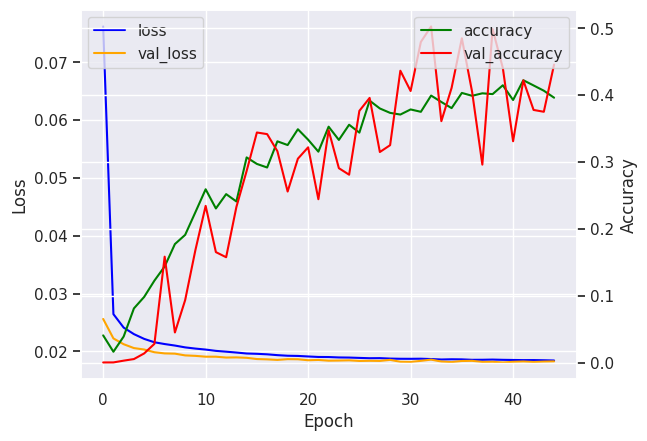

In [ ]:
plot_history(history)

2436/2436 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
9916/9916 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


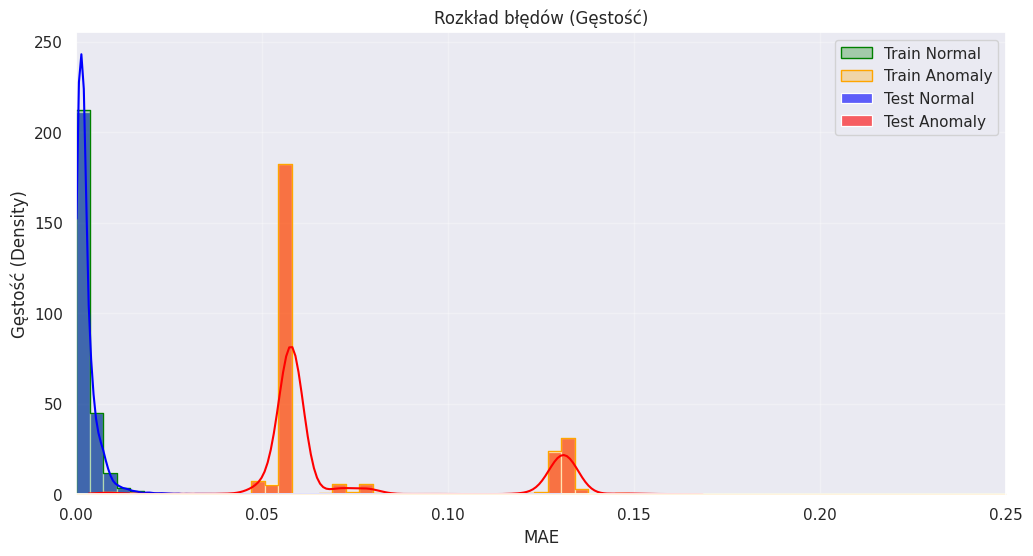

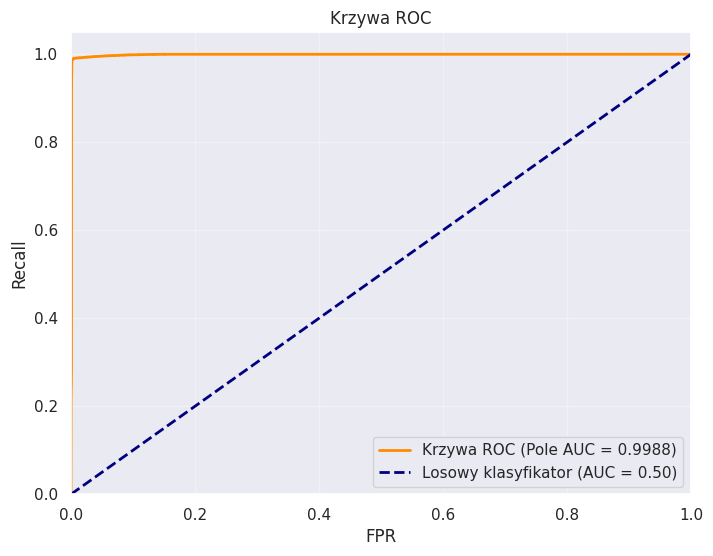

________________________________________
Wartość metryki AUC: 0.9988
Optymalny próg(wsk. J Youdena): 0.0394
Maksymalna wartość wsk J Youdena: 0.9864
________________________________________


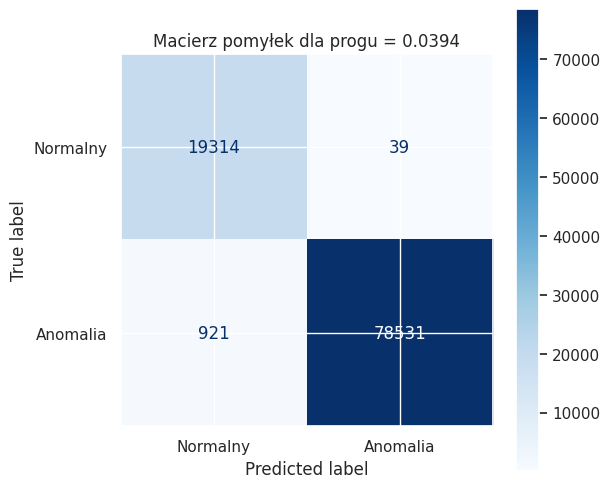

________________________________________

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

    Normalny       0.95      1.00      0.98     19353
    Anomalia       1.00      0.99      0.99     79452

    accuracy                           0.99     98805
   macro avg       0.98      0.99      0.98     98805
weighted avg       0.99      0.99      0.99     98805

Wskaźnik Fałszywych Alarmów (FPR): 0.20%
________________________________________


In [ ]:
generate_model_summary(autoencoder,
                           train_normal_prep, test_normal_prep, test_anom_prep, train_anom_prep)

### Wnioski

Wprowadzenie warstw Dropout poskutkowało wyraźnymi wahaniami accuracy na wykresie uczenia przy końcowej stracie na poziomie ok. 0.018. Wyznaczony próg odcięcia (0.0394) pozwolił zachować niski wskaźnik fałszywych alarmów (FPR = 0.20%) oraz wysokie AUC równe 0.9988. Zastosowanie tej regularyzacji wpłynęło jednak negatywnie na wykrywalność intruzów, generując aż 921 błędów False Negative, czyli o 140 przepuszczonych ataków więcej niż w modelu bazowym. Wprowadzony przez Dropout szum ograniczył pojemność autoenkodera.

## Przypadek 4

- Zwiększenie warstw/liczby jednostek w warstwach

#### a. Zwiększenie liczby jednostek

- (256) -> (64) -> (16) -> (64) -> (256)

In [ ]:
autoencoder = Sequential([
    Input(shape= (train_normal_prep.shape[1],)),

    Dense(256, activation='relu'),
    Dense(64, activation='relu'),
    
    Dense(16, activation='relu'),

    Dense(64, activation='relu'),
    Dense(256, activation='relu'),

    Dense(train_normal_prep.shape[1], activation='sigmoid')
])

In [ ]:
autoencoder.compile(
    optimizer= 'adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = autoencoder.fit(
    x=train_normal_prep, 
    y=train_normal_prep,
    epochs=100,
    batch_size=128,
    validation_data=(test_normal_prep, test_normal_prep),
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.0321 - loss: 0.0526 - val_accuracy: 0.0123 - val_loss: 0.0200
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0099 - loss: 0.0189 - val_accuracy: 0.0210 - val_loss: 0.0184
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0201 - loss: 0.0179 - val_accuracy: 0.0318 - val_loss: 0.0179
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0301 - loss: 0.0175 - val_accuracy: 0.0366 - val_loss: 0.0176
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0386 - loss: 0.0173 - val_accuracy: 0.0385 - val_loss: 0.0174
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0448 - loss: 0.0172 - val_accuracy: 0.0413 - val_loss: 0.0173
Epoch 7/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0491 - loss: 0.0171 - val_accuracy: 0.0420 - val_loss: 0.0172
Epoch 8/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0529 - loss: 0.0170 - val_accu

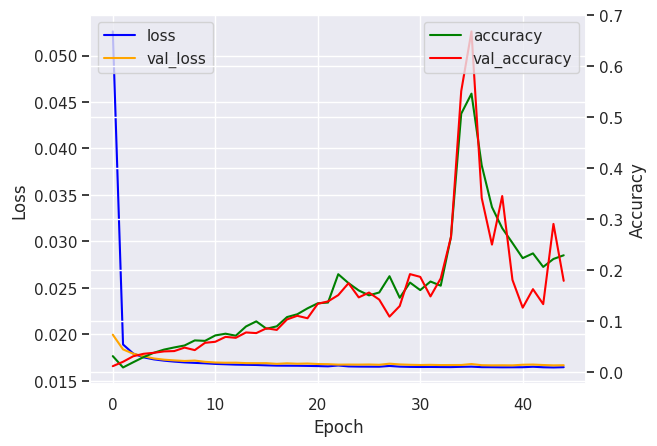

In [ ]:
plot_history(history)

2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
9916/9916 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


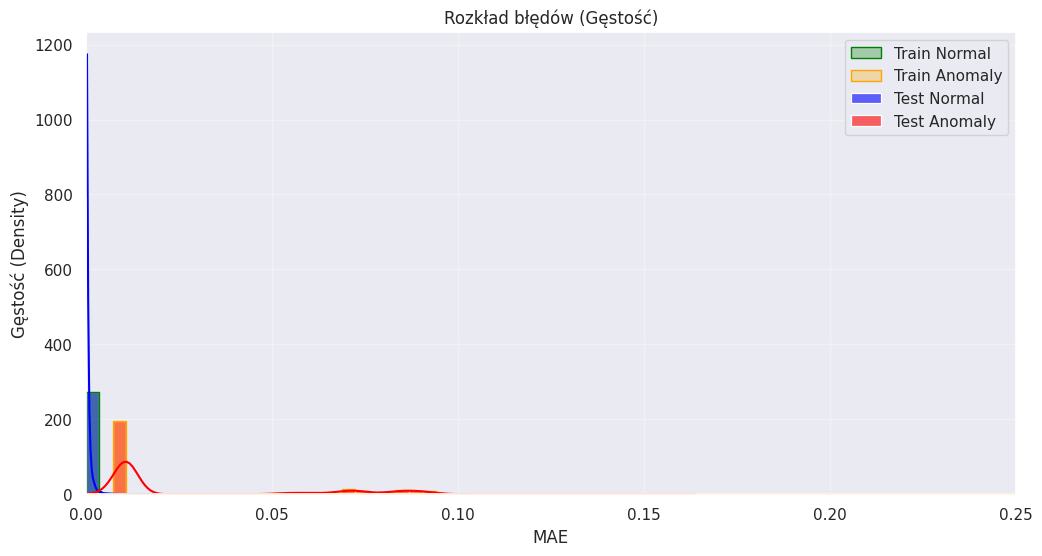

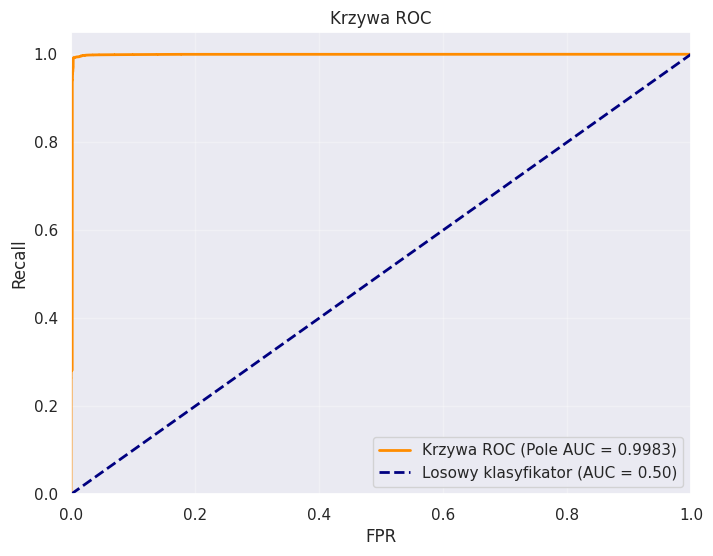

________________________________________
Wartość metryki AUC: 0.9983
Optymalny próg(wsk. J Youdena): 0.0075
Maksymalna wartość wsk J Youdena: 0.9880
________________________________________


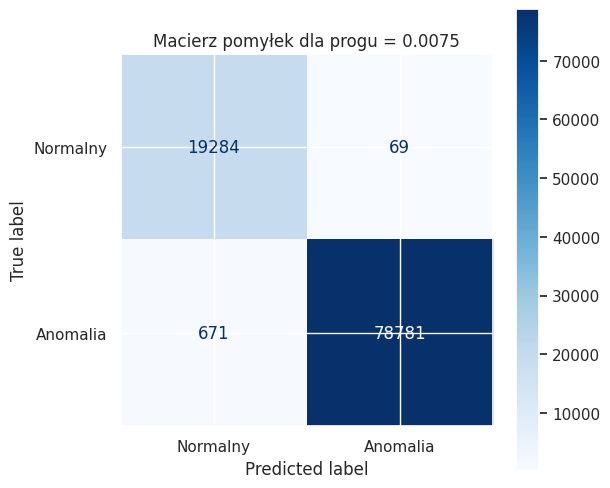

________________________________________

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

    Normalny       0.97      1.00      0.98     19353
    Anomalia       1.00      0.99      1.00     79452

    accuracy                           0.99     98805
   macro avg       0.98      0.99      0.99     98805
weighted avg       0.99      0.99      0.99     98805

Wskaźnik Fałszywych Alarmów (FPR): 0.36%
________________________________________


In [ ]:
generate_model_summary(autoencoder,
                           train_normal_prep, test_normal_prep, test_anom_prep, train_anom_prep)

#### b. Zwiększenie liczby warstw

- (128) -> (32) -> (16) -> (8) -> (16) -> (32) -> (128)

In [23]:
autoencoder = Sequential([
    Input(shape= (train_normal_prep.shape[1],)),

    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),

    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(128, activation='relu'),

    Dense(train_normal_prep.shape[1], activation='sigmoid')
])

In [24]:
autoencoder.compile(
    optimizer= 'adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

In [26]:
history = autoencoder.fit(
    x=train_normal_prep, 
    y=train_normal_prep,
    epochs=100,
    batch_size=128,
    validation_data=(test_normal_prep, test_normal_prep),
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.0792 - loss: 0.0877 - val_accuracy: 1.5501e-04 - val_loss: 0.0280
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 2.3099e-04 - loss: 0.0244 - val_accuracy: 5.6839e-04 - val_loss: 0.0228
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0015 - loss: 0.0219 - val_accuracy: 0.0123 - val_loss: 0.0211
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0188 - loss: 0.0206 - val_accuracy: 0.0453 - val_loss: 0.0202
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0464 - loss: 0.0198 - val_accuracy: 0.0544 - val_loss: 0.0196
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0629 - loss: 0.0193 - val_accuracy: 0.0744 - val_loss: 0.0192
Epoch 7/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0895 - loss: 0.0189 - val_accuracy: 0.0960 - val_loss: 0.0189
Epoch 8/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0966 - loss: 0.018

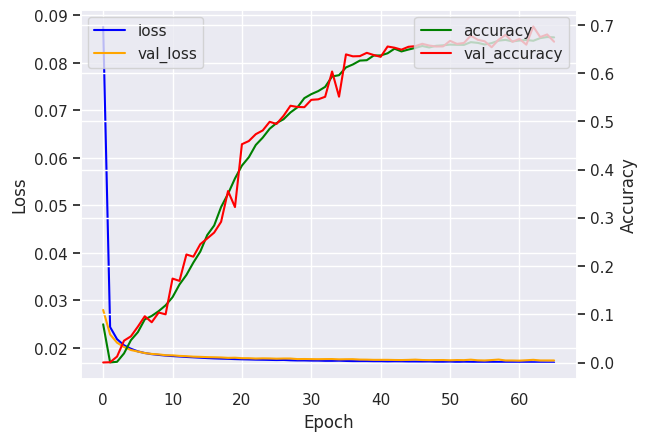

In [27]:
plot_history(history)

2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
9916/9916 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


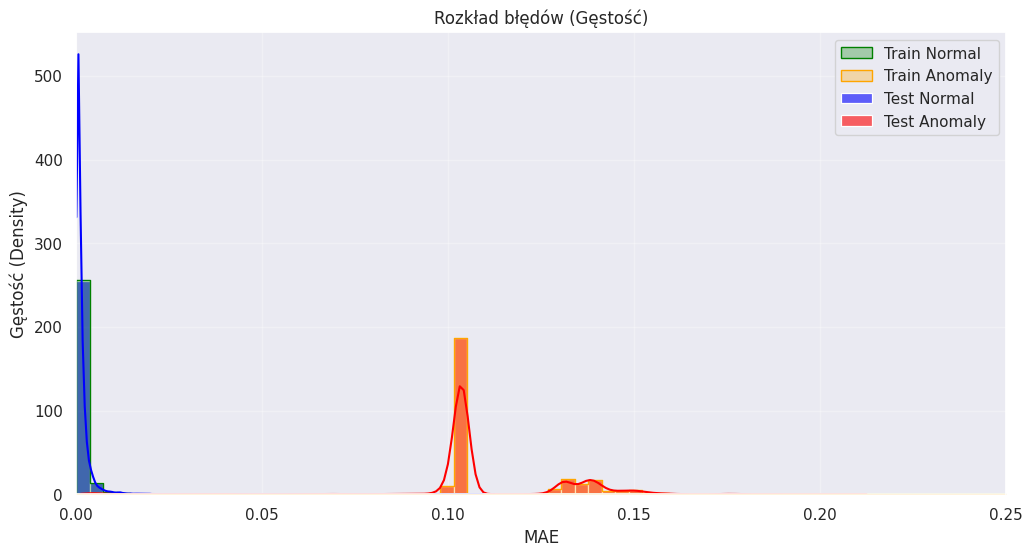

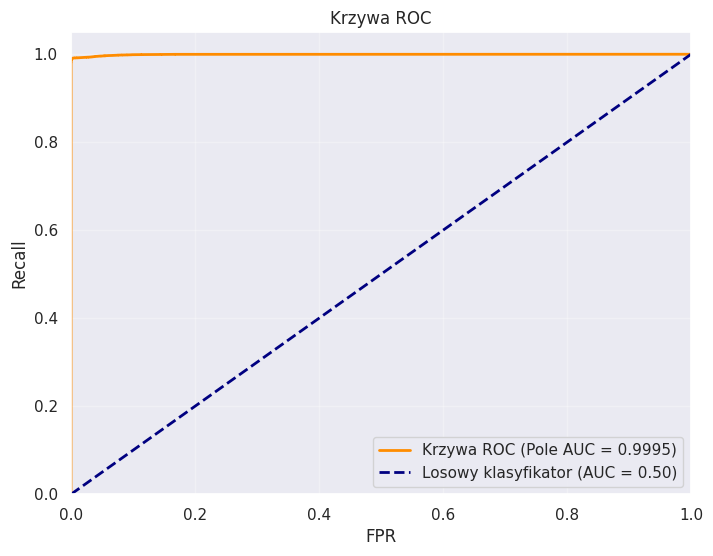

________________________________________
Wartość metryki AUC: 0.9995
Optymalny próg(wsk. J Youdena): 0.0265
Maksymalna wartość wsk J Youdena: 0.9886
________________________________________


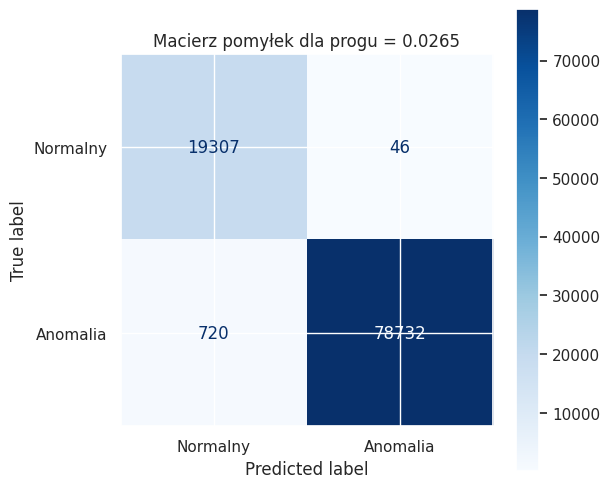

________________________________________

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

    Normalny       0.96      1.00      0.98     19353
    Anomalia       1.00      0.99      1.00     79452

    accuracy                           0.99     98805
   macro avg       0.98      0.99      0.99     98805
weighted avg       0.99      0.99      0.99     98805

Wskaźnik Fałszywych Alarmów (FPR): 0.24%
________________________________________


In [28]:
generate_model_summary(autoencoder,
                           train_normal_prep, test_normal_prep, test_anom_prep, train_anom_prep)

#### c. Zmniejszenie jednostek "wąskiego gardła"

- (128) -> (32) -> (16) -> (4) -> (16) -> (32) -> (128)

In [29]:
autoencoder = Sequential([
    Input(shape= (train_normal_prep.shape[1],)),

    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),

    Dense(4, activation='relu'),

    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(128, activation='relu'),

    Dense(train_normal_prep.shape[1], activation='sigmoid')
])

In [30]:
autoencoder.compile(
    optimizer= 'adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

In [32]:
history = autoencoder.fit(
    x=train_normal_prep, 
    y=train_normal_prep,
    epochs=100,
    batch_size=128,
    validation_data=(test_normal_prep, test_normal_prep),
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.2636 - loss: 0.0814 - val_accuracy: 0.5822 - val_loss: 0.0290
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6268 - loss: 0.0260 - val_accuracy: 0.6611 - val_loss: 0.0244
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6692 - loss: 0.0236 - val_accuracy: 0.6655 - val_loss: 0.0230
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6688 - loss: 0.0223 - val_accuracy: 0.6686 - val_loss: 0.0219
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6714 - loss: 0.0214 - val_accuracy: 0.6707 - val_loss: 0.0212
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6666 - loss: 0.0208 - val_accuracy: 0.6627 - val_loss: 0.0207
Epoch 7/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6594 - loss: 0.0204 - val_accuracy: 0.6551 - val_loss: 0.0203
Epoch 8/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6532 - loss: 0.0201 - val_accu

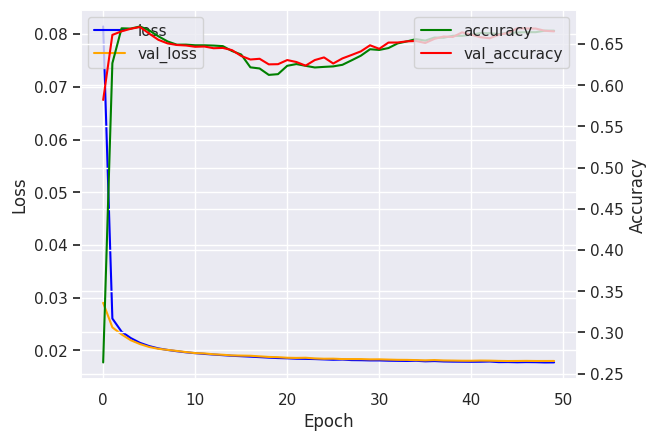

In [33]:
plot_history(history)

2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
9916/9916 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


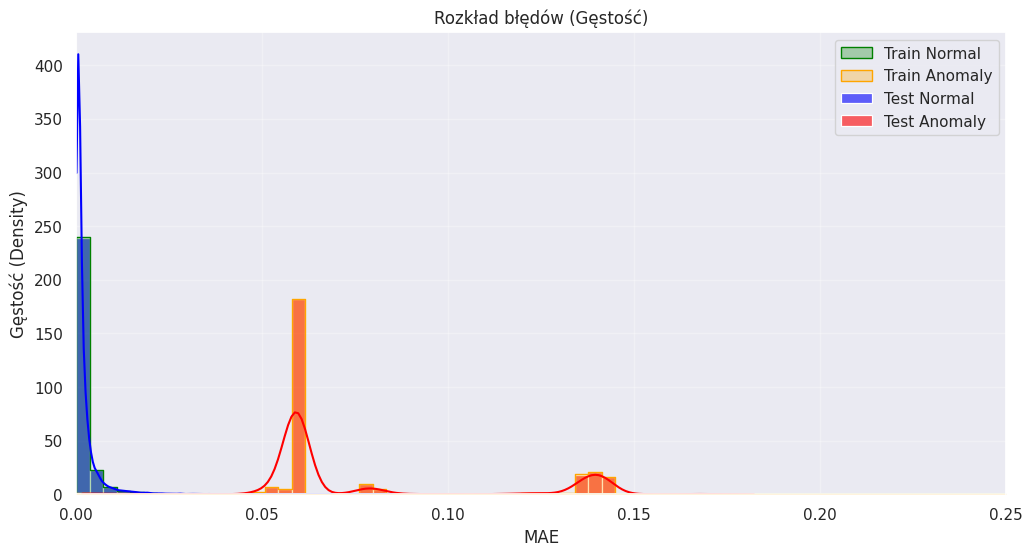

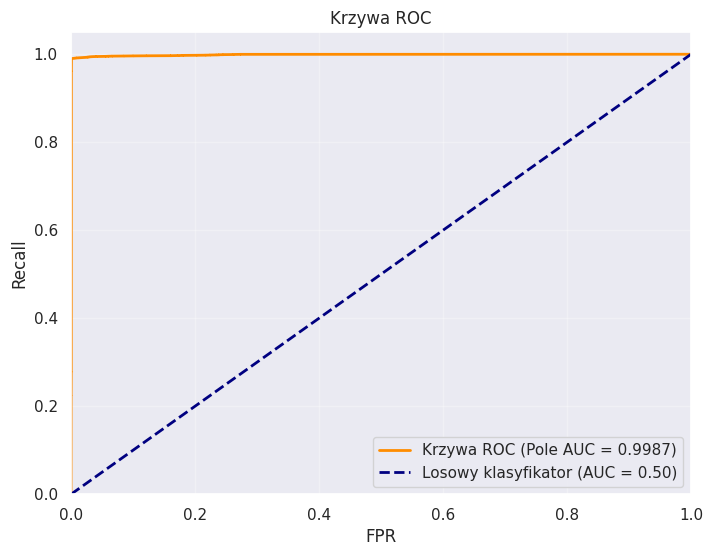

________________________________________
Wartość metryki AUC: 0.9987
Optymalny próg(wsk. J Youdena): 0.0472
Maksymalna wartość wsk J Youdena: 0.9891
________________________________________


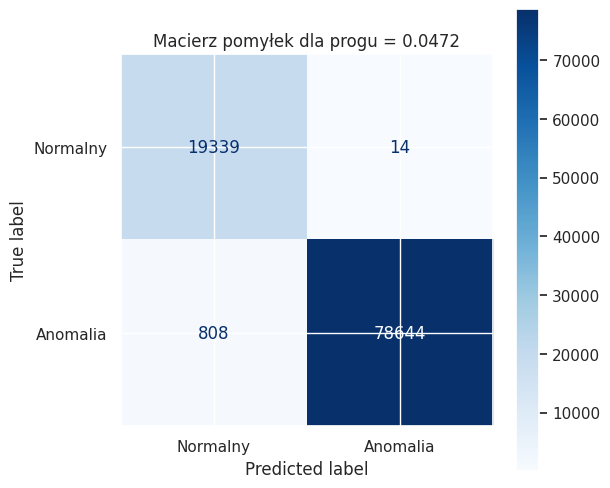

________________________________________

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

    Normalny       0.96      1.00      0.98     19353
    Anomalia       1.00      0.99      0.99     79452

    accuracy                           0.99     98805
   macro avg       0.98      0.99      0.99     98805
weighted avg       0.99      0.99      0.99     98805

Wskaźnik Fałszywych Alarmów (FPR): 0.07%
________________________________________


In [34]:
generate_model_summary(autoencoder,
                           train_normal_prep, test_normal_prep, test_anom_prep, train_anom_prep)

In [35]:
autoencoder = Sequential([
    Input(shape= (train_normal_prep.shape[1],)),

    Dense(64, activation='relu'),
    Dense(16, activation='relu'),

    Dense(4, activation='relu'),

    Dense(16, activation='relu'),
    Dense(64, activation='relu'),

    Dense(train_normal_prep.shape[1], activation='sigmoid')
])

In [36]:
autoencoder.compile(
    optimizer= 'adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

In [38]:
history = autoencoder.fit(
    x=train_normal_prep, 
    y=train_normal_prep,
    epochs=100,
    batch_size=128,
    validation_data=(test_normal_prep, test_normal_prep),
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.0839 - loss: 0.1064 - val_accuracy: 0.0000e+00 - val_loss: 0.0378
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2905 - loss: 0.0324 - val_accuracy: 0.4788 - val_loss: 0.0289
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4998 - loss: 0.0271 - val_accuracy: 0.6080 - val_loss: 0.0261
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5249 - loss: 0.0250 - val_accuracy: 0.5443 - val_loss: 0.0245
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4660 - loss: 0.0237 - val_accuracy: 0.4910 - val_loss: 0.0233
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3960 - loss: 0.0228 - val_accuracy: 0.3671 - val_loss: 0.0226
Epoch 7/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2817 - loss: 0.0221 - val_accuracy: 0.2868 - val_loss: 0.0220
Epoch 8/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1156 - loss: 0.0216 - val_

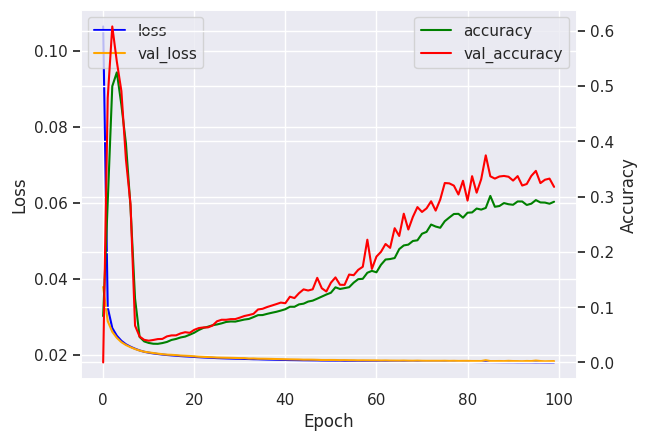

In [39]:
plot_history(history)

2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
9916/9916 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


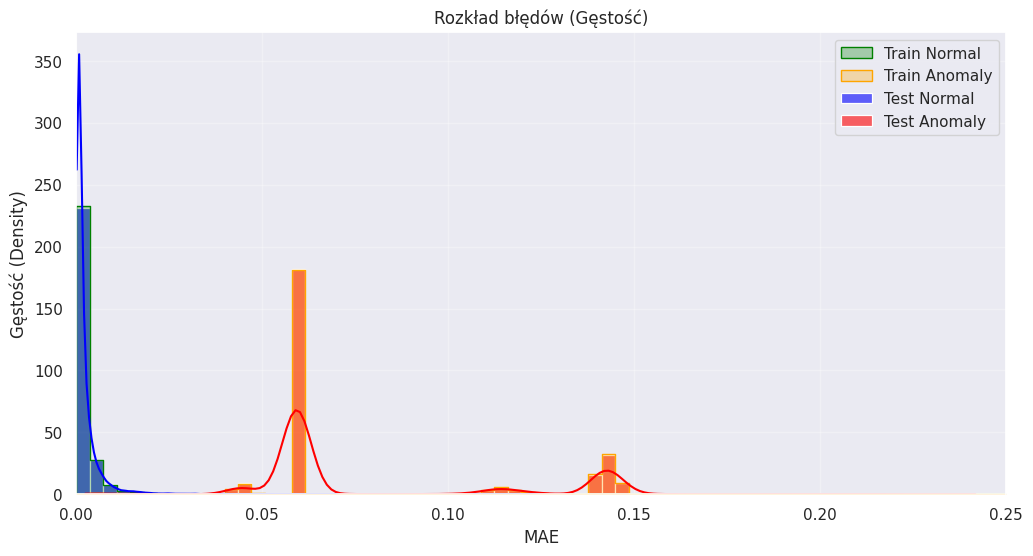

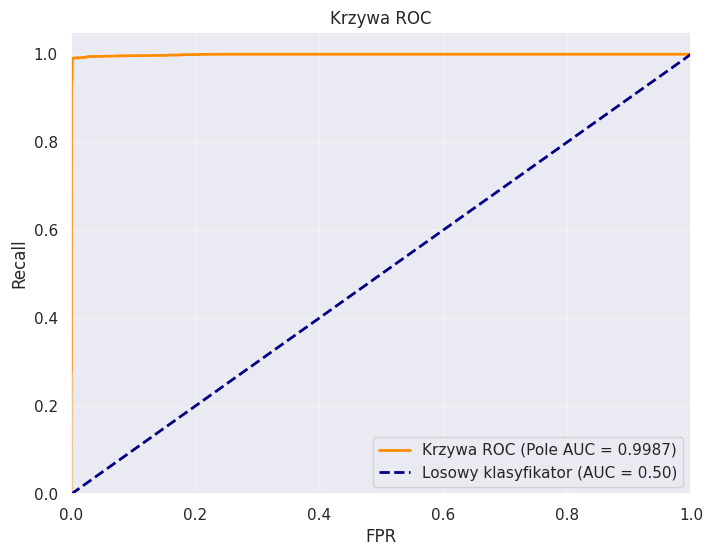

________________________________________
Wartość metryki AUC: 0.9987
Optymalny próg(wsk. J Youdena): 0.0415
Maksymalna wartość wsk J Youdena: 0.9888
________________________________________


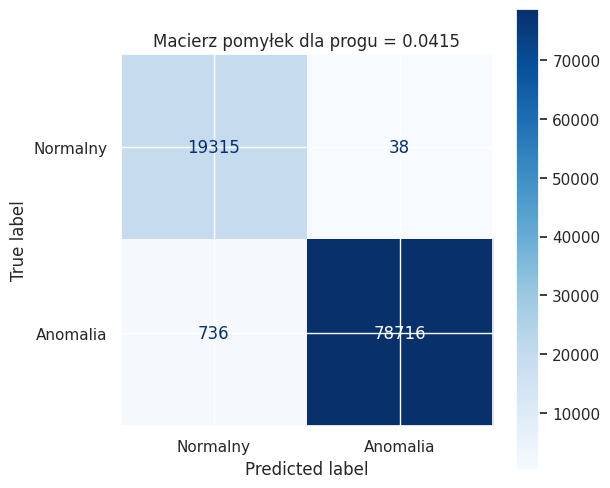

________________________________________

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

    Normalny       0.96      1.00      0.98     19353
    Anomalia       1.00      0.99      1.00     79452

    accuracy                           0.99     98805
   macro avg       0.98      0.99      0.99     98805
weighted avg       0.99      0.99      0.99     98805

Wskaźnik Fałszywych Alarmów (FPR): 0.20%
________________________________________


In [40]:
generate_model_summary(autoencoder,
                           train_normal_prep, test_normal_prep, test_anom_prep, train_anom_prep)

### Wnioski

**Przypadek 4.a**

Rozbudowanie warstw sieci wywołało wyraźną niestabilność podczas nauki, co objawiło się nagłym, chaotycznym skokiem skuteczności około 35. epoki. Mimo wysokiego końcowego wyniku ogólnego (AUC = 0.9983), większa pojemność modelu zmusiła system do ustawienia bardzo niskiego progu czułości. W efekcie ta konfiguracja wygenerowała najwięcej fałszywych alarmów w całym zestawieniu (0.36%, czyli 69 pomyłek na ponad 19 tysięcy normalnych próbek). Model wykrył 78 781 ataków, ale przepuścił 671 z nich. Przez swoją tendencję do niestabilnej pracy, wersja ta wypada najgorzej ze wszystkich badanych zmian architektury.

**Przypadek 4.b**

Zwiększenie głębokości sieci poprzez dodanie warstwy z 16 neuronami przed wąskim gardłem przyniosło znakomite rezultaty, gwarantując idealnie gładki i stabilny przebieg krzywych uczenia. Ta konfiguracja okazuje się najlepsza pod kątem ogólnej klasyfikacji, uzyskując najwyższy w całym projekcie wynik AUC równy 0.9995. Przy progu wynoszącym 0.0265 model zminimalizował liczbę przepuszczonych ataków do niespełna 720, zachowując przy tym bardzo niski poziom fałszywych alarmów (FPR = 0.24%, 46 pomyłek).

**Przypadek 4.c**

Zminimalizowanie wąskiego gardła do tylko 4 jednostek zmusiło autoenkoder do silnej selekcji cech ruchu sieciowego. Wynikiem tego jest świetna wartość wskaźnika FPR - 0.07% (zaledwie 14 pomyłek na ponad 19 tysięcy normalbych próbek). Ceną za tak wysoką precyzję stał się jednak spadek elastyczności modelu, przez co liczba przeoczonych ataków wzrosła do 808 (AUC = 0.9987).

## Wnioski

Najwyższą skuteczność i stabilność w detekcji anomalii zapewniło zastosowanie optymalizatora Adam w pogłębionej architekturze z wąskim gardłem o rozmiarze 8 (przypadek 4.b), która wygenerowała najmniej przeoczonych ataków przy rekordowym AUC równym 0.9995.